In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df=pd.read_csv("/content/adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.isnull()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32557,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32558,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
32559,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.replace("?",np.nan,inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_1173/3384611266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
print(df.duplicated().sum())

24


In [ ]:
df.drop_duplicates(inplace=True)

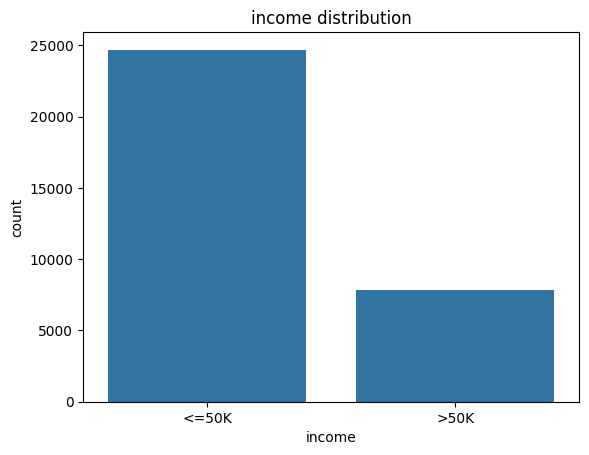

In [ ]:
sns.countplot(x='income',data=df)
plt.title("income distribution")
plt.show()

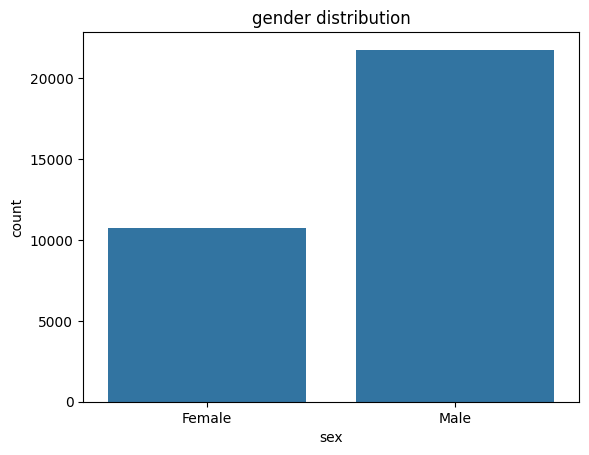

In [ ]:
sns.countplot(x='sex',data=df)
plt.title("gender distribution")
plt.show()

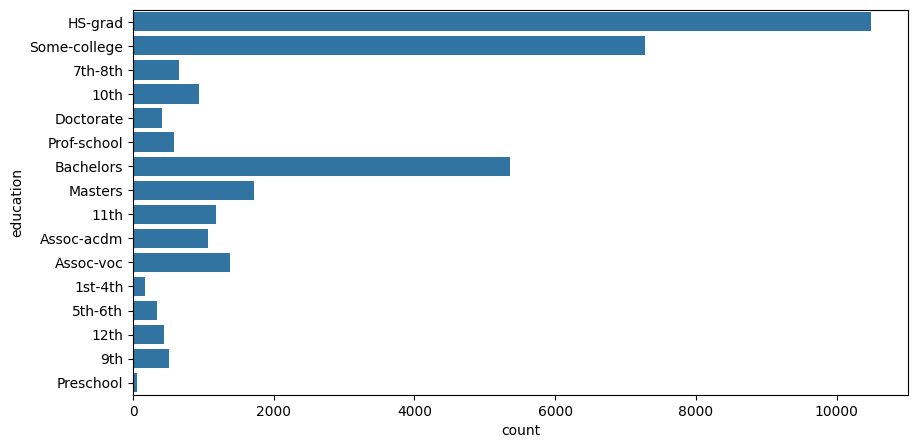

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='education',data=df)
plt.show()

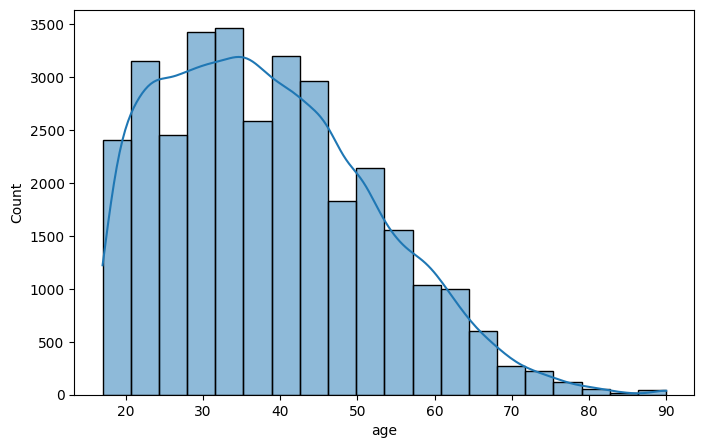

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=20,kde=True)
plt.show()

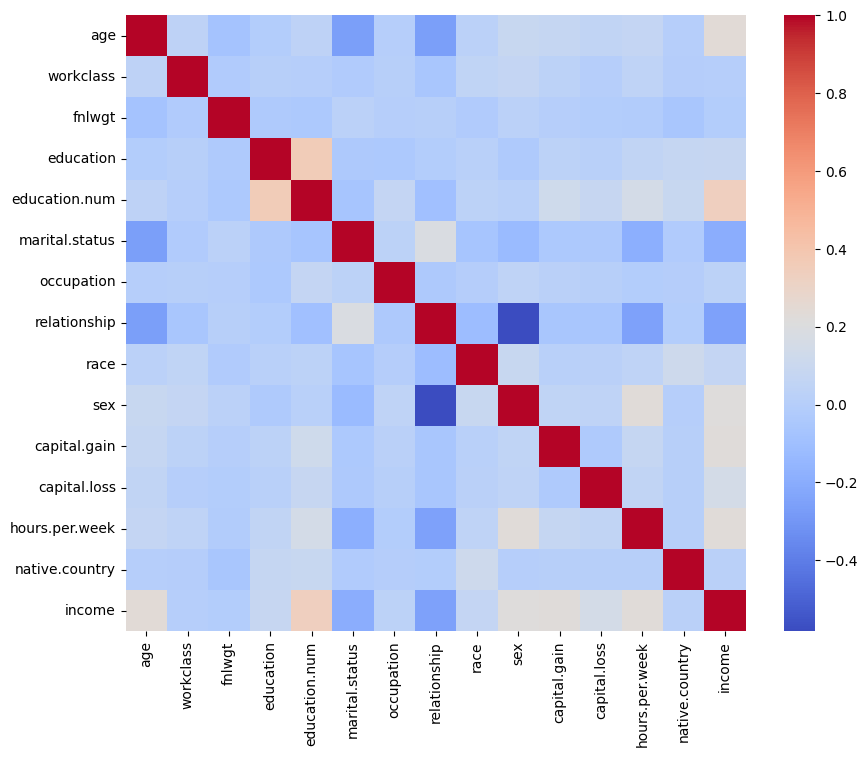

In [ ]:
temp = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in temp.select_dtypes(include='object').columns:
    temp[col] = le.fit_transform(temp[col])

plt.figure(figsize=(10,8))
sns.heatmap(temp.corr(), cmap="coolwarm")
plt.show()

In [ ]:
x=df.drop('income',axis=1)
y=df['income']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#catboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
cat_features=x.select_dtypes(include='object').columns
cat_features

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')

In [ ]:
cat_index=[x.columns.get_loc(col) for col in cat_features]

In [ ]:
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

model.fit(
    x_train,
    y_train,
    cat_features=cat_index
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, verbose=0)

In [ ]:
y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8716963736939152


In [ ]:
#adabosst
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

le = LabelEncoder()

for col in df2.select_dtypes(include='object').columns:
    df2[col] = le.fit_transform(df2[col])


In [ ]:
X = df2.drop("income",axis=1)

y = df2["income"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1,
    random_state=42
)

model.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=42)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.8581745543945912


In [ ]:
#catboost example
# New person's details
new_person = pd.DataFrame({
    'age': [35],
    'workclass': ['Private'],
    'fnlwgt': [180000],
    'education': ['Bachelors'],
    'education.num': [13],
    'marital.status': ['Married-civ-spouse'],
    'occupation': ['Prof-specialty'],
    'relationship': ['Husband'],
    'race': ['White'],
    'sex': ['Male'],
    'capital.gain': [5000],
    'capital.loss': [0],
    'hours.per.week': [45],
    'native.country': ['United-States']
})

# Apply LabelEncoder to each object column in new_person
# NOTE: This re-initializes LabelEncoder for each column and maps the single unique value to 0.
# This might not be consistent with how the training data (X_train) was encoded,
# potentially affecting prediction accuracy. A more robust solution would use the
# same fitted encoders from the training data for each specific column.
from sklearn.preprocessing import LabelEncoder
for col in new_person.select_dtypes(include='object').columns:
    temp_le = LabelEncoder()
    new_person[col] = temp_le.fit_transform(new_person[col])

prediction = model.predict(new_person)

print("Prediction:", prediction)

if prediction[0] == 1: # Assuming '>50K' was encoded as 1 and '<=50K' as 0
    print("Income is greater than $50K")
else:
    print("Income is less than or equal to $50K")

Prediction: [1]
Income is greater than $50K
